In [7]:
import pandas as pd

train_behaviors = pd.read_csv(
    "../data/raw/MINDsmall_train/behaviors.tsv",
    sep="\t",
    header=None
)

train_news = pd.read_csv(
    "../data/raw/MINDsmall_train/news.tsv",
    sep="\t",
    header=None
)

print("train_behaviors shape:", train_behaviors.shape)
print("train_news shape:", train_news.shape)
train_behaviors.head()

train_behaviors shape: (156965, 5)
train_news shape: (51282, 8)


,0,1,2,3,4
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


In [8]:
train_behaviors.columns = [
    "impression_id",
    "user_id",
    "time",
    "history",
    "impressions"
]

train_behaviors.head()

,impression_id,user_id,time,history,impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


查看缺失情况

In [9]:
train_behaviors.isnull().sum()

impression_id       0
user_id             0
time                0
history          3238
impressions         0
dtype: int64

统计历史点击长度

In [10]:
def history_len(x):
    if pd.isna(x) or x == "":
        return 0
    return len(str(x).split(" "))

train_behaviors["history_len"] = train_behaviors["history"].apply(history_len)
train_behaviors["history_len"].describe()

count    156965.000000
mean         32.539987
std          40.267607
min           0.000000
25%           8.000000
50%          19.000000
75%          42.000000
max         558.000000
Name: history_len, dtype: float64

Matplotlib is building the font cache; this may take a moment.


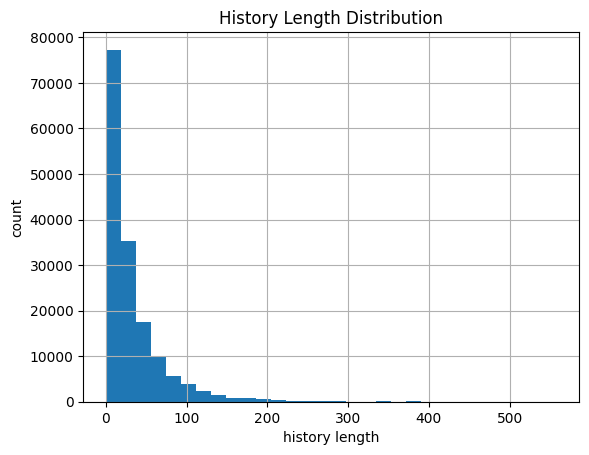

In [11]:
import matplotlib.pyplot as plt

train_behaviors["history_len"].hist(bins=30)
plt.title("History Length Distribution")
plt.xlabel("history length")
plt.ylabel("count")
plt.show()